--- Initialisation du banc d'essai pour BRVMTrainingManager (Hebdomadaire) ---
Chemin ajouté: /Users/naofal/Desktop/Mémoire/mistral
✅ Importation de BRVMTrainingManager réussie.

--- Chargement des données pré-traitées ---
✅ 'all_data.pkl' chargé. Shape: (6386, 225)
✅ 'dividendes.pkl' chargé. Shape: (27, 46)
✅ 'fundamentals_panel.pkl' chargé. Shape: (300142, 16)

--- Affichage des données chargées ---

--- Exemple de données pour ABJC ---
Price       Close  High  Low  Open  Volume
Date                                      
1998-09-16    NaN   NaN  NaN   NaN     NaN
1998-09-18    NaN   NaN  NaN   NaN     NaN
1998-09-21    NaN   NaN  NaN   NaN     NaN
1998-09-23    NaN   NaN  NaN   NaN     NaN
1998-09-25    NaN   NaN  NaN   NaN     NaN

--- Colonnes de fundamentals_panel ---
['nb_actions', 'Sector_AGRICULTURE', 'Sector_DISTRIBUTION', 'Sector_FINANCE', 'Sector_INDUSTRY', 'Sector_OTHER', 'Sector_PUBLIC SERVICE', 'Sector_TRANSPORT', 'Country_BENIN', 'Country_BURKINA FASO']

🧪 VALIDATION DE

Préparation des prix:   0%|          | 0/45 [00:00<?, ?it/s]

Génération de la liste Top-K:   0%|          | 0/260 [00:00<?, ?it/s]

✅ Top-K généré : 260 dates avec 10 actifs sélectionnés

📊 TRAIN: 260 périodes de rééquilibrage
Espacement entre dates: 7 jours
Première date: 2018-01-02 00:00:00
Dernière date: 2022-12-28 00:00:00

📅 Génération des dates de rééquilibrage pour 'VALIDATION'...
   -> 52 dates générées.
Pré-traitement des données pour le Top-K...


Préparation des prix:   0%|          | 0/45 [00:00<?, ?it/s]

...

Préparation des prix:   0%|          | 0/45 [00:00<?, ?it/s]

Génération de la liste Top-K:   0%|          | 0/53 [00:00<?, ?it/s]

✅ Top-K généré : 53 dates avec 10 actifs sélectionnés

📊 TEST: 53 périodes de rééquilibrage
Espacement entre dates: 7 jours
Première date: 2024-01-02 00:00:00
Dernière date: 2024-12-31 00:00:00

--- Test de génération des indicateurs ---


Calcul des indicateurs:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Indicateurs générés : 30 observations pour la période 'train'

✅ Indicateurs générés pour 3 dates
Shape des indicateurs: (30, 20)

--- Exemple d'indicateurs pour un actif ---
                  MACD        RSI         CCI     STOCH_K      WILLR  \
Date                                                                   
2018-01-02  137.579355  81.902611  168.094910  100.000000  -0.000000   
2018-01-09   -4.875974  50.075400   19.641640   43.601286 -56.398714   
2018-01-16  -51.094771  52.637369  -11.898764   19.794872 -80.205128   

               BB_Upper  BB_Middle     BB_Lower          EMA         ATR  \
Date                                                                       
2018-01-02  4611.158290    3670.40  2729.641710  3986.050239  233.912714   
2018-01-09  4851.272502    3888.30  2925.327498  4085.232255  230.633092   
2018-01-16  4736.707463    4060.85  3384.992537  4032.232734  188.567998   

                   SAR  Close_Lag1  Close_Lag3  Close_Lag5   SMA_50   SMA_20  \
D

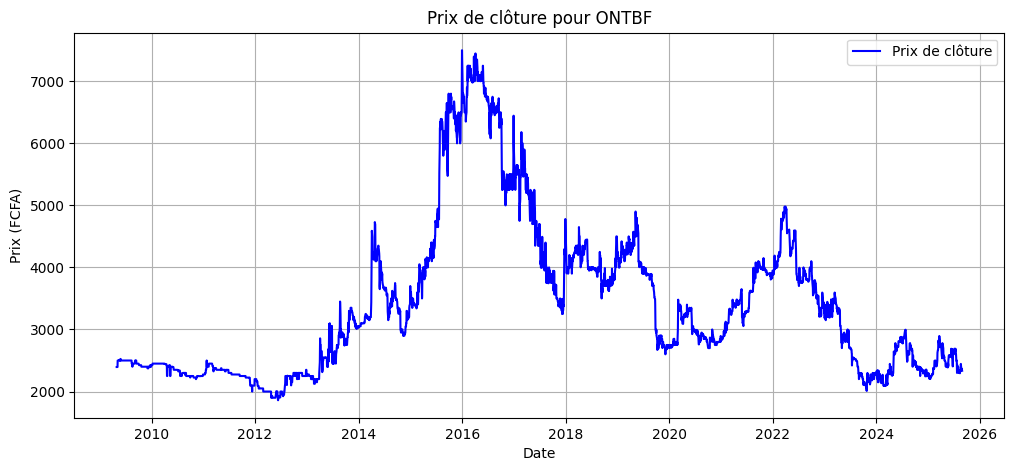

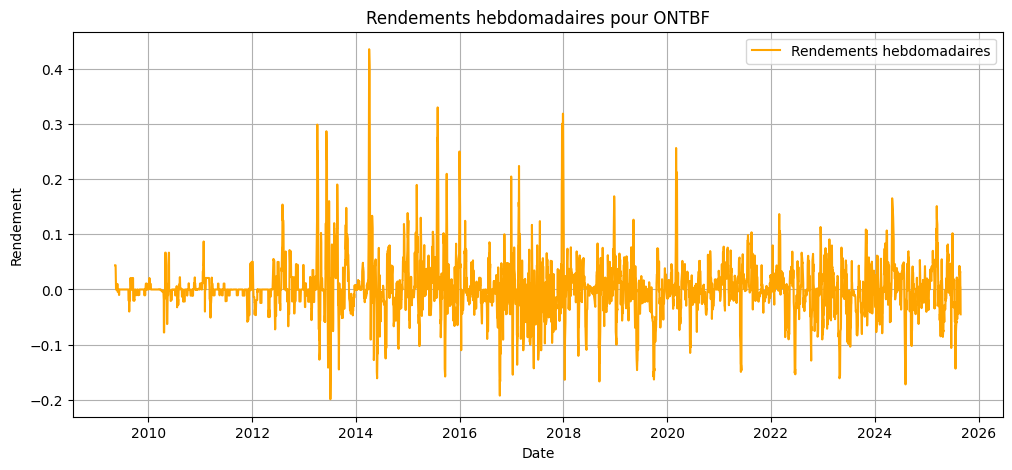


📝 RÉSUMÉ DE LA VALIDATION

Validation du gestionnaire de données (Fréquence hebdomadaire):
- Périodes d'entraînement: 260 dates
- Périodes de validation: 52 dates
- Périodes de test: 53 dates
- Nombre d'indicateurs techniques générés: 20
- Actifs uniques dans Top-K: 40


✅✅✅ VALIDATION HEBDOMADAIRE TERMINÉE AVEC SUCCÈS ! ✅✅✅


In [1]:
# =============================================================================
# VALIDATION DU MODULE DE GESTION DE DONNÉES (BRVMTrainingManager) - HEBDOMADAIRE
# =============================================================================
# === CELLULE 1: IMPORTS ET CONFIGURATION ===
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("--- Initialisation du banc d'essai pour BRVMTrainingManager (Hebdomadaire) ---")

# Configuration des chemins
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Chemin ajouté: {module_path}")

try:
    from src.data_manager import BRVMTrainingManager
    print("✅ Importation de BRVMTrainingManager réussie.")
except ImportError as e:
    print(f"❌ ERREUR D'IMPORTATION: {e}")
    raise

# === CELLULE 2: CHARGEMENT DES DONNÉES ===
print("\n--- Chargement des données pré-traitées ---")
try:
    base_path = '..'
    processed_data_path = os.path.join(base_path, 'processed_data')

    with open(os.path.join(processed_data_path, 'all_data.pkl'), 'rb') as f:
        all_data = pickle.load(f)
    print(f"✅ 'all_data.pkl' chargé. Shape: {all_data.shape}")

    with open(os.path.join(processed_data_path, 'dividendes.pkl'), 'rb') as f:
        dividendes = pickle.load(f)
    print(f"✅ 'dividendes.pkl' chargé. Shape: {dividendes.shape}")

    with open(os.path.join(processed_data_path, 'fundamentals_panel.pkl'), 'rb') as f:
        fundamentals_panel = pickle.load(f)
    print(f"✅ 'fundamentals_panel.pkl' chargé. Shape: {fundamentals_panel.shape}")

except Exception as e:
    print(f"❌ ERREUR DE CHARGEMENT: {e}")
    print("Assurez-vous d'avoir exécuté '00_pretraitement.ipynb'.")
    raise

# === CELLULE 3: AFFICHAGE DES DONNÉES ===
print("\n--- Affichage des données chargées ---")

# Exemple de 'all_data' pour un actif
sample_ticker = all_data.columns.get_level_values(0).unique()[0]
print(f"\n--- Exemple de données pour {sample_ticker} ---")
print(all_data[sample_ticker].head())

# Colonnes de 'fundamentals_panel'
print("\n--- Colonnes de fundamentals_panel ---")
print(fundamentals_panel.columns.tolist()[:10])  # Afficher les 10 premières colonnes

# === CELLULE 4: VALIDATION HEBDOMADAIRE ===
print("\n" + "="*60)
print("🧪 VALIDATION DE LA FRÉQUENCE HEBDOMADAIRE (7 jours)")
print("="*60)

manager_hebdo = BRVMTrainingManager(
    all_data=all_data,
    dividendes=dividendes,
    fundamentals_panel=fundamentals_panel,
    rebalancing_freq_days=7  # Fréquence hebdomadaire
)

# === CELLULE 5: VALIDATION DES DONNÉES ===
print("\n--- Validation de l'intégrité des données ---")
manager_hebdo.validate_data_integrity()

# === CELLULE 6: TEST DES PÉRIODES D'ENTRAÎNEMENT ===
print("\n--- Génération des dates de rééquilibrage ---")

# Test pour toutes les périodes
periods = ['train', 'validation', 'test']
topk_results = {}

for period in periods:
    topk_dates = manager_hebdo.generate_topk_dates_for_period(period, K=10)
    topk_results[period] = topk_dates
    print(f"\n📊 {period.upper()}: {len(topk_dates)} périodes de rééquilibrage")
    
    if len(topk_dates) > 1:
        delta = topk_dates[1][0] - topk_dates[0][0]
        print(f"Espacement entre dates: {delta.days} jours")
        print(f"Première date: {topk_dates[0][0]}")
        print(f"Dernière date: {topk_dates[-1][0]}")

# === CELLULE 7: GÉNÉRATION DES INDICATEURS ===
print("\n--- Test de génération des indicateurs ---")

# Génération des indicateurs pour les 3 premières dates d'entraînement
sample_topk = topk_results['train'][:3]
indicators_sample = manager_hebdo.generate_indicators_for_period('train', sample_topk, window_size=70)

print(f"\n✅ Indicateurs générés pour {len(sample_topk)} dates")
print(f"Shape des indicateurs: {indicators_sample.shape}")

if not indicators_sample.empty:
    first_asset = indicators_sample.index.get_level_values(1)[0]
    print("\n--- Exemple d'indicateurs pour un actif ---")
    print(indicators_sample.xs(first_asset, level=1).head())

# === CELLULE 8: VISUALISATION ===
print("\n--- Visualisation des données ---")

# Sélection d'un actif exemple
ticker_example = topk_results['train'][0][1][0]  # Premier actif du Top-K
close_prices = all_data[ticker_example]['Close'].dropna()

# Prix de clôture
plt.figure(figsize=(12, 5))
plt.plot(close_prices.index, close_prices, label='Prix de clôture', color='blue')
plt.title(f"Prix de clôture pour {ticker_example}")
plt.xlabel("Date")
plt.ylabel("Prix (FCFA)")
plt.grid(True)
plt.legend()
plt.show()

# Rendements hebdomadaires
weekly_returns = close_prices.pct_change(7).dropna()  # Rendements sur 7 jours
plt.figure(figsize=(12, 5))
plt.plot(weekly_returns.index, weekly_returns, label='Rendements hebdomadaires', color='orange')
plt.title(f"Rendements hebdomadaires pour {ticker_example}")
plt.xlabel("Date")
plt.ylabel("Rendement")
plt.grid(True)
plt.legend()
plt.show()

# === CELLULE 9: RÉSUMÉ ===
print("\n" + "="*60)
print("📝 RÉSUMÉ DE LA VALIDATION")
print("="*60)

print(f"""
Validation du gestionnaire de données (Fréquence hebdomadaire):
- Périodes d'entraînement: {len(topk_results['train'])} dates
- Périodes de validation: {len(topk_results['validation'])} dates
- Périodes de test: {len(topk_results['test'])} dates
- Nombre d'indicateurs techniques générés: {indicators_sample.shape[1] if not indicators_sample.empty else 0}
- Actifs uniques dans Top-K: {len(set([a for _, assets in topk_results['train'] for a in assets]))}
""")

print("\n✅✅✅ VALIDATION HEBDOMADAIRE TERMINÉE AVEC SUCCÈS ! ✅✅✅")